# Pretraitement
Redimensionnement, HSV/grayscale, filtrage, histogrammes.

## Description du pretraitement
Ce pretraitement uniformise la taille des images, reduit le bruit et rend les distributions de couleurs comparables.
- Redimensionnement: standardiser l entree pour ML/DL.
- RGB -> HSV et grayscale: separer information couleur et texture.
- Filtrage (Gaussian/Median): reduire le bruit tout en preservant les contours.
Les figures ci dessous montrent l impact visuel des transformations et les histogrammes confirment la redistribution des intensites.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "../data/dataset_tomato/Tomato_healthy/0a31e630-0d98-416b-b0e4-88a88aad1dc5___RS_HL 9653.JPG"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
img_resize = cv2.resize(img_rgb, (224, 224))
img_hsv = cv2.cvtColor(img_resize, cv2.COLOR_RGB2HSV)
img_gray = cv2.cvtColor(img_resize, cv2.COLOR_RGB2GRAY)


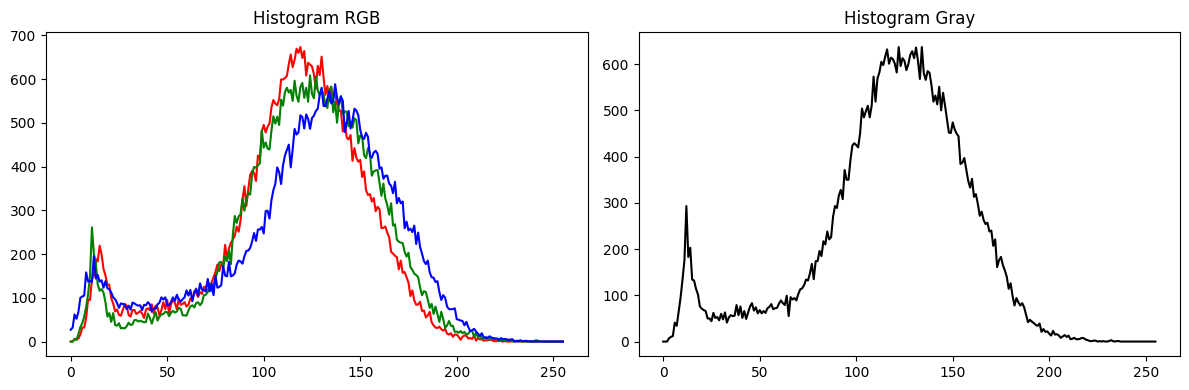

In [4]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.title("Histogram RGB")
for i, col in enumerate(["r","g","b"]):
    hist = cv2.calcHist([img_resize], [i], None, [256], [0,256])
    plt.plot(hist, color=col)

plt.subplot(1,2,2)
plt.title("Histogram Gray")
hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0,256])
plt.plot(hist_gray, color="black")
plt.tight_layout()
plt.show()

## Analyse des histogrammes
- RGB: un pic tres fort indique une couleur dominante (souvent le vert de la feuille).
- Gray: une distribution serree indique peu de contraste; une distribution etalee indique plus de details et texture.
- Apres filtrage, les histogrammes deviennent plus lisses, signe d une reduction du bruit.
- Si les histogrammes sont tres differents entre images, cela peut indiquer des variations d eclairage a corriger.